In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# Fix random seeds for reproducibility (MANDATORY per project)
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Configuration
# ============================================================
DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
NUM_CLASSES = 14
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 14 disease labels exactly as in the dataset
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]

print(f"Device: {DEVICE}")
print(f"Data directory: {DATA_DIR}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Labels: {LABELS}")

Device: cuda
Data directory: /kaggle/input/datasets/organizations/nih-chest-xrays/data
Number of classes: 14
Labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']


In [2]:
# ============================================================
# CELL 2: Load and Explore Metadata
# ============================================================
df = pd.read_csv(os.path.join(DATA_DIR, 'Data_Entry_2017.csv'))

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (112120, 12)

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First few rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
# ============================================================
# CELL 3: Multi-hot Encoding + Patient-wise Splits
# ============================================================

# Step 1: Create multi-hot encoded label columns
for label in LABELS:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x.split('|') else 0)

print("Label distribution (positive cases):")
print(df[LABELS].sum().sort_values(ascending=False))

# Step 2: Patient-wise split (MANDATORY - prevents data leakage)
unique_patients = df['Patient ID'].unique()
print(f"\nTotal unique patients: {len(unique_patients)}")

# Split patients (not images) into train/val/test: 70/10/20
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=SEED
)
train_patients, val_patients = train_test_split(
    train_patients, test_size=0.125, random_state=SEED  # 0.125 x 0.8 = 0.1
)

# Step 3: Assign images based on patient splits
train_df = df[df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = df[df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df  = df[df['Patient ID'].isin(test_patients)].reset_index(drop=True)

print(f"\nTrain images: {len(train_df)}")
print(f"Val images:   {len(val_df)}")
print(f"Test images:  {len(test_df)}")

# Step 4: Verify NO patient leakage
train_pat = set(train_df['Patient ID'])
val_pat   = set(val_df['Patient ID'])
test_pat  = set(test_df['Patient ID'])

print(f"\nLeakage check:")
print(f"Train-Val overlap: {len(train_pat & val_pat)} patients (must be 0)")
print(f"Train-Test overlap: {len(train_pat & test_pat)} patients (must be 0)")
print(f"Val-Test overlap: {len(val_pat & test_pat)} patients (must be 0)")

Label distribution (positive cases):
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64

Total unique patients: 30805

Train images: 78614
Val images:   11212
Test images:  22294

Leakage check:
Train-Val overlap: 0 patients (must be 0)
Train-Test overlap: 0 patients (must be 0)
Val-Test overlap: 0 patients (must be 0)


In [4]:
# ============================================================
# CELL 4: Build Image Paths + PyTorch Dataset Class
# ============================================================

# Step 1: Map image filenames to full paths across all 12 folders
image_path_map = {}
for folder in [f'images_{str(i).zfill(3)}' for i in range(1, 13)]:
    folder_path = os.path.join(DATA_DIR, folder, 'images')
    if os.path.exists(folder_path):
        for fname in os.listdir(folder_path):
            image_path_map[fname] = os.path.join(folder_path, fname)

print(f"Total images mapped: {len(image_path_map)}")

# Step 2: Define transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Step 3: PyTorch Dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_path_map, labels, transform=None):
        self.df = dataframe
        self.image_path_map = image_path_map
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_path_map.get(row['Image Index'], None)

        # Load image
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Get multi-hot label vector
        label = torch.tensor(row[self.labels].values.astype(float), dtype=torch.float32)
        return img, label

# Step 4: Create datasets
train_dataset = ChestXrayDataset(train_df, image_path_map, LABELS, train_transforms)
val_dataset   = ChestXrayDataset(val_df,   image_path_map, LABELS, val_test_transforms)
test_dataset  = ChestXrayDataset(test_df,  image_path_map, LABELS, val_test_transforms)

# Step 5: Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Step 6: Verify one batch
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Total images mapped: 112120
Train batches: 2457
Val batches:   351
Test batches:  697

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32, 14])


In [5]:
# ============================================================
# CELL 5: Compute Class Weights for Imbalance Handling
# ============================================================

# Count positive and negative cases per label in training set
pos_counts = train_df[LABELS].sum().values  # positive cases per label
neg_counts = len(train_df) - pos_counts     # negative cases per label

# Class weight = neg/pos ratio (higher weight for rare diseases)
pos_weights = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(DEVICE)

print("Class weights (higher = rarer disease):")
for label, weight in zip(LABELS, pos_weights.cpu().numpy()):
    print(f"  {label:<25} {weight:.2f}")

Class weights (higher = rarer disease):
  Atelectasis               8.67
  Cardiomegaly              40.14
  Effusion                  7.28
  Infiltration              4.71
  Mass                      17.95
  Nodule                    16.47
  Pneumonia                 79.30
  Pneumothorax              19.55
  Consolidation             22.85
  Edema                     48.95
  Emphysema                 43.69
  Fibrosis                  66.54
  Pleural_Thickening        32.28
  Hernia                    523.09


In [6]:
# ============================================================
# CELL 6: Loss Function + Model Definitions
# ============================================================

# BCE = Binary Cross Entropy
# pos_weight tells BCE to penalize missing rare diseases harder
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# ============================================================
# MODEL 1: ResNet-18 with Transfer Learning
# ============================================================
# ResNet = Residual Network (a CNN architecture)
# 18 = number of layers
# Transfer Learning = reuse a model already trained on ImageNet
#                     instead of starting from scratch

def get_resnet18():
    model = models.resnet18(weights='IMAGENET1K_V1')  # load pretrained weights
    # Replace the final layer to output 14 classes instead of 1000
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    return model.to(DEVICE)

# ============================================================
# MODEL 2: VGG-19 with Transfer Learning
# ============================================================
# VGG = Visual Geometry Group (creators of this architecture)
# 19 = number of layers

def get_vgg19():
    model = models.vgg19(weights='IMAGENET1K_V1')
    
    # Freeze all feature extraction layers
    # We only want to train the final classifier
    for param in model.features.parameters():
        param.requires_grad = False
    
    # Replace final classifier layer
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, NUM_CLASSES)
    
    return model.to(DEVICE)

# ============================================================
# MODEL 3: Custom CNN (built from scratch — NOT pretrained)
# ============================================================
# CNN = Convolutional Neural Network
# Conv = Convolution (a filter that scans the image looking for patterns)
# BN = Batch Normalization (keeps numbers stable during training)
# ReLU = Rectified Linear Unit (activation function — adds non-linearity)
# FC = Fully Connected layer (final decision-making layer)

class CustomCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv layer
            nn.BatchNorm2d(32),                           # BN
            nn.ReLU(inplace=True),                        # ReLU
            nn.MaxPool2d(2, 2),                           # shrink image by half

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),   # resize feature map to 4x4
            nn.Flatten(),                   # flatten to 1D vector
            nn.Linear(256 * 4 * 4, 512),   # FC layer
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),                # randomly turn off 50% neurons to prevent overfitting
            nn.Linear(512, num_classes)     # final output: 14 scores
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_custom_cnn():
    return CustomCNN().to(DEVICE)

# Test all three models
resnet18  = get_resnet18()
vgg19     = get_vgg19()
custom    = get_custom_cnn()

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"ResNet-18 trainable parameters:  {count_params(resnet18):,}")
print(f"VGG-19 trainable parameters:     {count_params(vgg19):,}")
print(f"Custom CNN trainable parameters: {count_params(custom):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 245MB/s]


ResNet-18 trainable parameters:  11,183,694
VGG-19 trainable parameters:     119,603,214
Custom CNN trainable parameters: 2,494,222


In [7]:
# ============================================================
# CELL 7: Training and Validation Functions
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    # Put model in training mode
    # (BN and Dropout behave differently during training vs evaluation)
    model.train()
    
    total_loss = 0
    
    for images, labels in loader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero out previous gradients
        # Gradient = direction to adjust the knobs
        optimizer.zero_grad()
        
        # Forward pass = model makes predictions
        outputs = model(images)
        
        # Calculate loss = how wrong was the model?
        loss = criterion(outputs, labels)
        
        # Backward pass = calculate which knobs to adjust
        loss.backward()
        
        # Update the knobs
        optimizer.step()
        
        total_loss += loss.item()
    
    # Return average loss across all batches
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    # Put model in evaluation mode
    # (turns off Dropout, BN uses stored statistics)
    model.eval()
    
    total_loss = 0
    all_labels  = []
    all_outputs = []
    
    # torch.no_grad() = don't calculate gradients during evaluation
    # saves memory and speeds up evaluation
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Sigmoid converts raw scores to probabilities (0 to 1)
            # Raw score of 2.5 → sigmoid → 0.92 (92% chance of disease)
            probs = torch.sigmoid(outputs)
            
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(probs.cpu().numpy())
    
    # Stack all batches into one array
    all_labels  = np.vstack(all_labels)
    all_outputs = np.vstack(all_outputs)
    
    avg_loss = total_loss / len(loader)
    
    # AUROC = Area Under ROC Curve
    # ROC = Receiver Operating Characteristic
    # Measures how well model separates sick from healthy patients
    # Score of 1.0 = perfect, 0.5 = random guessing
    auroc_scores = []
    for i in range(NUM_CLASSES):
        # Only calculate if both classes present in this batch
        if len(np.unique(all_labels[:, i])) > 1:
            auroc_scores.append(roc_auc_score(all_labels[:, i], all_outputs[:, i]))
        else:
            auroc_scores.append(0.0)
    
    mean_auroc = np.mean(auroc_scores)
    
    return avg_loss, mean_auroc, auroc_scores, all_labels, all_outputs


def train_model(model, model_name, train_loader, val_loader, 
                criterion, device, num_epochs=NUM_EPOCHS, lr=LR):
    
    # Adam = Adaptive Moment Estimation
    # A smart optimizer that adjusts LR automatically per parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # LR Scheduler = reduces LR when model stops improving
    # Patience=3 means: if no improvement for 3 epochs, reduce LR
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.5
    )
    
    
    best_auroc = 0
    best_model_path = f'/kaggle/working/{model_name}_best.pth'
    
    train_losses = []
    val_losses   = []
    val_aurocs   = []
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        # Evaluate on validation set
        val_loss, val_auroc, _, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Update LR scheduler
        scheduler.step(val_auroc)
        
        # Save best model checkpoint
        if val_auroc > best_auroc:
            best_auroc = val_auroc
            torch.save(model.state_dict(), best_model_path)
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val AUROC: {val_auroc:.4f} ← BEST SAVED")
        else:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val AUROC: {val_auroc:.4f}")
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aurocs.append(val_auroc)
    
    print(f"\nBest Val AUROC for {model_name}: {best_auroc:.4f}")
    print(f"Checkpoint saved to: {best_model_path}")
    
    return train_losses, val_losses, val_aurocs, best_model_path

print("Training and evaluation functions defined successfully.")

Training and evaluation functions defined successfully.


In [8]:
# ============================================================
# CELL 8: Train ResNet-18
# ============================================================

resnet18 = get_resnet18()  # fresh model

resnet18_train_losses, resnet18_val_losses, resnet18_val_aurocs, resnet18_checkpoint = train_model(
    model       = resnet18,
    model_name  = 'ResNet18',
    train_loader= train_loader,
    val_loader  = val_loader,
    criterion   = criterion,
    device      = DEVICE,
    num_epochs  = NUM_EPOCHS,
    lr          = LR
)

print("\nResNet-18 Training Complete!")


Training ResNet18
Epoch [1/10] Train Loss: 1.1283 | Val Loss: 1.0322 | Val AUROC: 0.7965 ← BEST SAVED
Epoch [2/10] Train Loss: 1.0349 | Val Loss: 1.0460 | Val AUROC: 0.7960
Epoch [3/10] Train Loss: 0.9938 | Val Loss: 1.0022 | Val AUROC: 0.8094 ← BEST SAVED
Epoch [4/10] Train Loss: 0.9710 | Val Loss: 0.9711 | Val AUROC: 0.8156 ← BEST SAVED
Epoch [5/10] Train Loss: 0.9436 | Val Loss: 0.9654 | Val AUROC: 0.8161 ← BEST SAVED
Epoch [6/10] Train Loss: 0.9205 | Val Loss: 1.0262 | Val AUROC: 0.8111
Epoch [7/10] Train Loss: 0.8993 | Val Loss: 0.9686 | Val AUROC: 0.8184 ← BEST SAVED
Epoch [8/10] Train Loss: 0.8788 | Val Loss: 1.0018 | Val AUROC: 0.8160
Epoch [9/10] Train Loss: 0.8585 | Val Loss: 1.0135 | Val AUROC: 0.8224 ← BEST SAVED
Epoch [10/10] Train Loss: 0.8436 | Val Loss: 1.0670 | Val AUROC: 0.8052

Best Val AUROC for ResNet18: 0.8224
Checkpoint saved to: /kaggle/working/ResNet18_best.pth

ResNet-18 Training Complete!


In [9]:
# ============================================================
# CELL 9: Train VGG-19 (Fixed - Lower LR + Frozen Features)
# ============================================================

vgg19 = get_vgg19()

vgg19_train_losses, vgg19_val_losses, vgg19_val_aurocs, vgg19_checkpoint = train_model(
    model        = vgg19,
    model_name   = 'VGG19',
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = DEVICE,
    num_epochs   = NUM_EPOCHS,
    lr           = 1e-5
)

print("\nVGG-19 Training Complete!")


Training VGG19
Epoch [1/10] Train Loss: 1.2468 | Val Loss: 1.1692 | Val AUROC: 0.7164 ← BEST SAVED
Epoch [2/10] Train Loss: 1.1812 | Val Loss: 1.1366 | Val AUROC: 0.7326 ← BEST SAVED
Epoch [3/10] Train Loss: 1.1604 | Val Loss: 1.1357 | Val AUROC: 0.7388 ← BEST SAVED
Epoch [4/10] Train Loss: 1.1432 | Val Loss: 1.1208 | Val AUROC: 0.7408 ← BEST SAVED
Epoch [5/10] Train Loss: 1.1301 | Val Loss: 1.1210 | Val AUROC: 0.7451 ← BEST SAVED
Epoch [6/10] Train Loss: 1.1177 | Val Loss: 1.1154 | Val AUROC: 0.7452 ← BEST SAVED
Epoch [7/10] Train Loss: 1.1133 | Val Loss: 1.1329 | Val AUROC: 0.7473 ← BEST SAVED
Epoch [8/10] Train Loss: 1.1006 | Val Loss: 1.1106 | Val AUROC: 0.7514 ← BEST SAVED
Epoch [9/10] Train Loss: 1.0889 | Val Loss: 1.1422 | Val AUROC: 0.7511
Epoch [10/10] Train Loss: 1.0874 | Val Loss: 1.1091 | Val AUROC: 0.7520 ← BEST SAVED

Best Val AUROC for VGG19: 0.7520
Checkpoint saved to: /kaggle/working/VGG19_best.pth

VGG-19 Training Complete!


In [10]:
# ============================================================
# CELL 10: Train Custom CNN
# ============================================================

custom_cnn = get_custom_cnn()  # fresh model

custom_train_losses, custom_val_losses, custom_val_aurocs, custom_checkpoint = train_model(
    model        = custom_cnn,
    model_name   = 'CustomCNN',
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = DEVICE,
    num_epochs   = NUM_EPOCHS,
    lr           = LR
)

print("\nCustom CNN Training Complete!")


Training CustomCNN
Epoch [1/10] Train Loss: 1.2855 | Val Loss: 1.2413 | Val AUROC: 0.6533 ← BEST SAVED
Epoch [2/10] Train Loss: 1.2517 | Val Loss: 1.2230 | Val AUROC: 0.6659 ← BEST SAVED
Epoch [3/10] Train Loss: 1.2357 | Val Loss: 1.2154 | Val AUROC: 0.6764 ← BEST SAVED
Epoch [4/10] Train Loss: 1.2253 | Val Loss: 1.2027 | Val AUROC: 0.6930 ← BEST SAVED
Epoch [5/10] Train Loss: 1.2199 | Val Loss: 1.2023 | Val AUROC: 0.6985 ← BEST SAVED
Epoch [6/10] Train Loss: 1.2128 | Val Loss: 1.1826 | Val AUROC: 0.7042 ← BEST SAVED
Epoch [7/10] Train Loss: 1.2037 | Val Loss: 1.1769 | Val AUROC: 0.7168 ← BEST SAVED
Epoch [8/10] Train Loss: 1.1970 | Val Loss: 1.1886 | Val AUROC: 0.7114
Epoch [9/10] Train Loss: 1.1905 | Val Loss: 1.1541 | Val AUROC: 0.7260 ← BEST SAVED
Epoch [10/10] Train Loss: 1.1871 | Val Loss: 1.1529 | Val AUROC: 0.7246

Best Val AUROC for CustomCNN: 0.7260
Checkpoint saved to: /kaggle/working/CustomCNN_best.pth

Custom CNN Training Complete!


In [11]:
# ============================================================
# CELL 10b: Verify All Checkpoints Exist
# ============================================================
import os

checkpoints = [
    '/kaggle/working/ResNet18_best.pth',
    '/kaggle/working/VGG19_best.pth', 
    '/kaggle/working/CustomCNN_best.pth'
]

for cp in checkpoints:
    if os.path.exists(cp):
        size = os.path.getsize(cp) / 1024 / 1024
        print(f"✓ {cp} exists ({size:.1f} MB)")
    else:
        print(f"✗ {cp} MISSING")

✓ /kaggle/working/ResNet18_best.pth exists (42.7 MB)
✓ /kaggle/working/VGG19_best.pth exists (532.7 MB)
✓ /kaggle/working/CustomCNN_best.pth exists (9.5 MB)


In [12]:
# ============================================================
# CELL 11: Full Evaluation - Per-label AUROC/PR-AUC Table
# ============================================================

def full_evaluation(model, model_name, test_loader, criterion, device, checkpoint_path):
    # Load best checkpoint
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    
    all_labels  = []
    all_outputs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(probs.cpu().numpy())
    
    all_labels  = np.vstack(all_labels)
    all_outputs = np.vstack(all_outputs)
    
    # Per-label AUROC and PR-AUC
    results = []
    for i, label in enumerate(LABELS):
        if len(np.unique(all_labels[:, i])) > 1:
            auroc  = roc_auc_score(all_labels[:, i], all_outputs[:, i])
            pr_auc = average_precision_score(all_labels[:, i], all_outputs[:, i])
        else:
            auroc  = 0.0
            pr_auc = 0.0
        results.append({'Label': label, 'AUROC': auroc, 'PR-AUC': pr_auc})
    
    results_df = pd.DataFrame(results)
    
    # Thresholded metrics at 0.5
    preds_binary = (all_outputs >= 0.5).astype(int)
    micro_f1  = f1_score(all_labels, preds_binary, average='micro', zero_division=0)
    macro_f1  = f1_score(all_labels, preds_binary, average='macro', zero_division=0)
    micro_p   = precision_score(all_labels, preds_binary, average='micro', zero_division=0)
    micro_r   = recall_score(all_labels, preds_binary, average='micro', zero_division=0)
    mean_auroc = results_df['AUROC'].mean()
    mean_prauc = results_df['PR-AUC'].mean()
    
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS: {model_name}")
    print(f"{'='*60}")
    print(f"\nPer-label AUROC and PR-AUC:")
    print(results_df.to_string(index=False))
    print(f"\nMean AUROC:     {mean_auroc:.4f}")
    print(f"Mean PR-AUC:    {mean_prauc:.4f}")
    print(f"Micro F1:       {micro_f1:.4f}")
    print(f"Macro F1:       {macro_f1:.4f}")
    print(f"Micro Precision:{micro_p:.4f}")
    print(f"Micro Recall:   {micro_r:.4f}")
    
    return results_df, mean_auroc, mean_prauc, micro_f1, macro_f1

print("Evaluation function defined.")

Evaluation function defined.


In [13]:
# ============================================================
# CELL 12: Compare All Three Models
# ============================================================

# Load best checkpoints and evaluate all three models
resnet18_eval, r18_auroc, r18_prauc, r18_mf1, r18_Mf1 = full_evaluation(
    get_resnet18(), 'ResNet-18', test_loader, criterion, DEVICE, '/kaggle/working/ResNet18_best.pth'
)

vgg19_eval, v19_auroc, v19_prauc, v19_mf1, v19_Mf1 = full_evaluation(
    get_vgg19(), 'VGG-19', test_loader, criterion, DEVICE, '/kaggle/working/VGG19_best.pth'
)

custom_eval, cnn_auroc, cnn_prauc, cnn_mf1, cnn_Mf1 = full_evaluation(
    get_custom_cnn(), 'CustomCNN', test_loader, criterion, DEVICE, '/kaggle/working/CustomCNN_best.pth'
)

# Summary comparison table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
summary = pd.DataFrame({
    'Model':      ['ResNet-18', 'VGG-19', 'Custom CNN'],
    'Mean AUROC': [r18_auroc,   v19_auroc,  cnn_auroc],
    'Mean PR-AUC':[r18_prauc,   v19_prauc,  cnn_prauc],
    'Micro F1':   [r18_mf1,     v19_mf1,    cnn_mf1],
    'Macro F1':   [r18_Mf1,     v19_Mf1,    cnn_Mf1],
})
print(summary.to_string(index=False))


EVALUATION RESULTS: ResNet-18

Per-label AUROC and PR-AUC:
             Label    AUROC   PR-AUC
       Atelectasis 0.787148 0.287416
      Cardiomegaly 0.896740 0.287334
          Effusion 0.867440 0.479354
      Infiltration 0.697235 0.343787
              Mass 0.807182 0.240721
            Nodule 0.726127 0.180778
         Pneumonia 0.718724 0.032788
      Pneumothorax 0.856593 0.282363
     Consolidation 0.803917 0.150078
             Edema 0.875068 0.144384
         Emphysema 0.902963 0.297064
          Fibrosis 0.800568 0.091269
Pleural_Thickening 0.796066 0.119021
            Hernia 0.914266 0.244302

Mean AUROC:     0.8179
Mean PR-AUC:    0.2272
Micro F1:       0.2373
Macro F1:       0.2070
Micro Precision:0.1428
Micro Recall:   0.7012

EVALUATION RESULTS: VGG-19

Per-label AUROC and PR-AUC:
             Label    AUROC   PR-AUC
       Atelectasis 0.723264 0.215866
      Cardiomegaly 0.794862 0.135452
          Effusion 0.790743 0.312755
      Infiltration 0.664481 0.313850
    

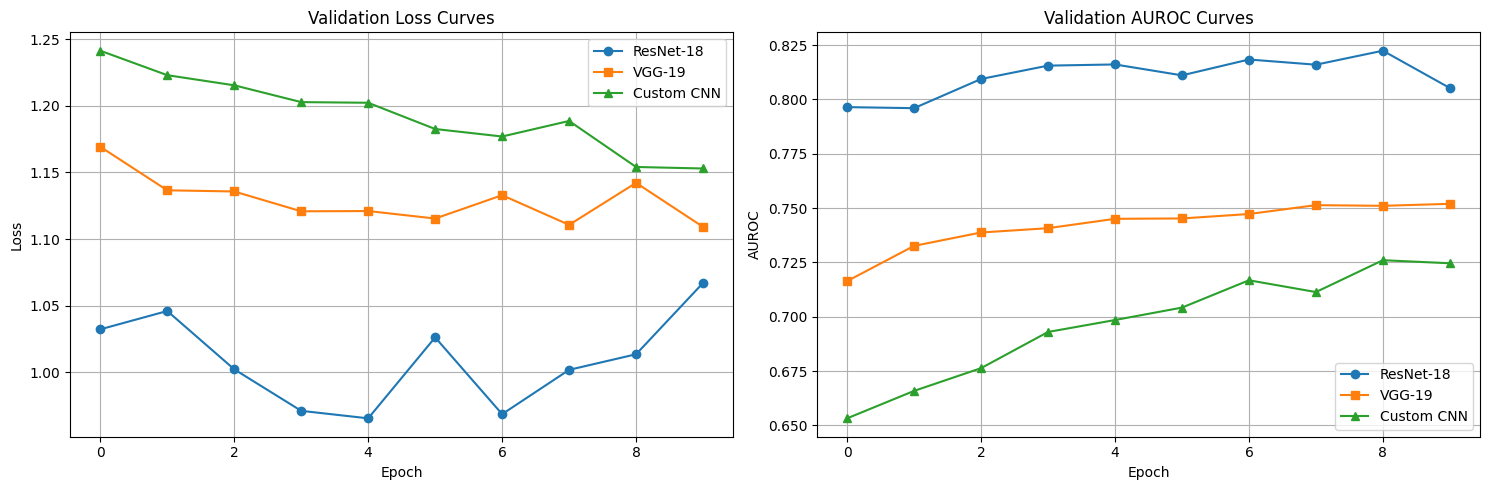

Learning curves saved.


In [14]:
# ============================================================
# CELL 13: Learning Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Validation Loss
axes[0].plot(resnet18_val_losses,  label='ResNet-18',  marker='o')
axes[0].plot(vgg19_val_losses,     label='VGG-19',     marker='s')
axes[0].plot(custom_val_losses,    label='Custom CNN', marker='^')
axes[0].set_title('Validation Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Validation AUROC
axes[1].plot(resnet18_val_aurocs,  label='ResNet-18',  marker='o')
axes[1].plot(vgg19_val_aurocs,     label='VGG-19',     marker='s')
axes[1].plot(custom_val_aurocs,    label='Custom CNN', marker='^')
axes[1].set_title('Validation AUROC Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curves saved.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


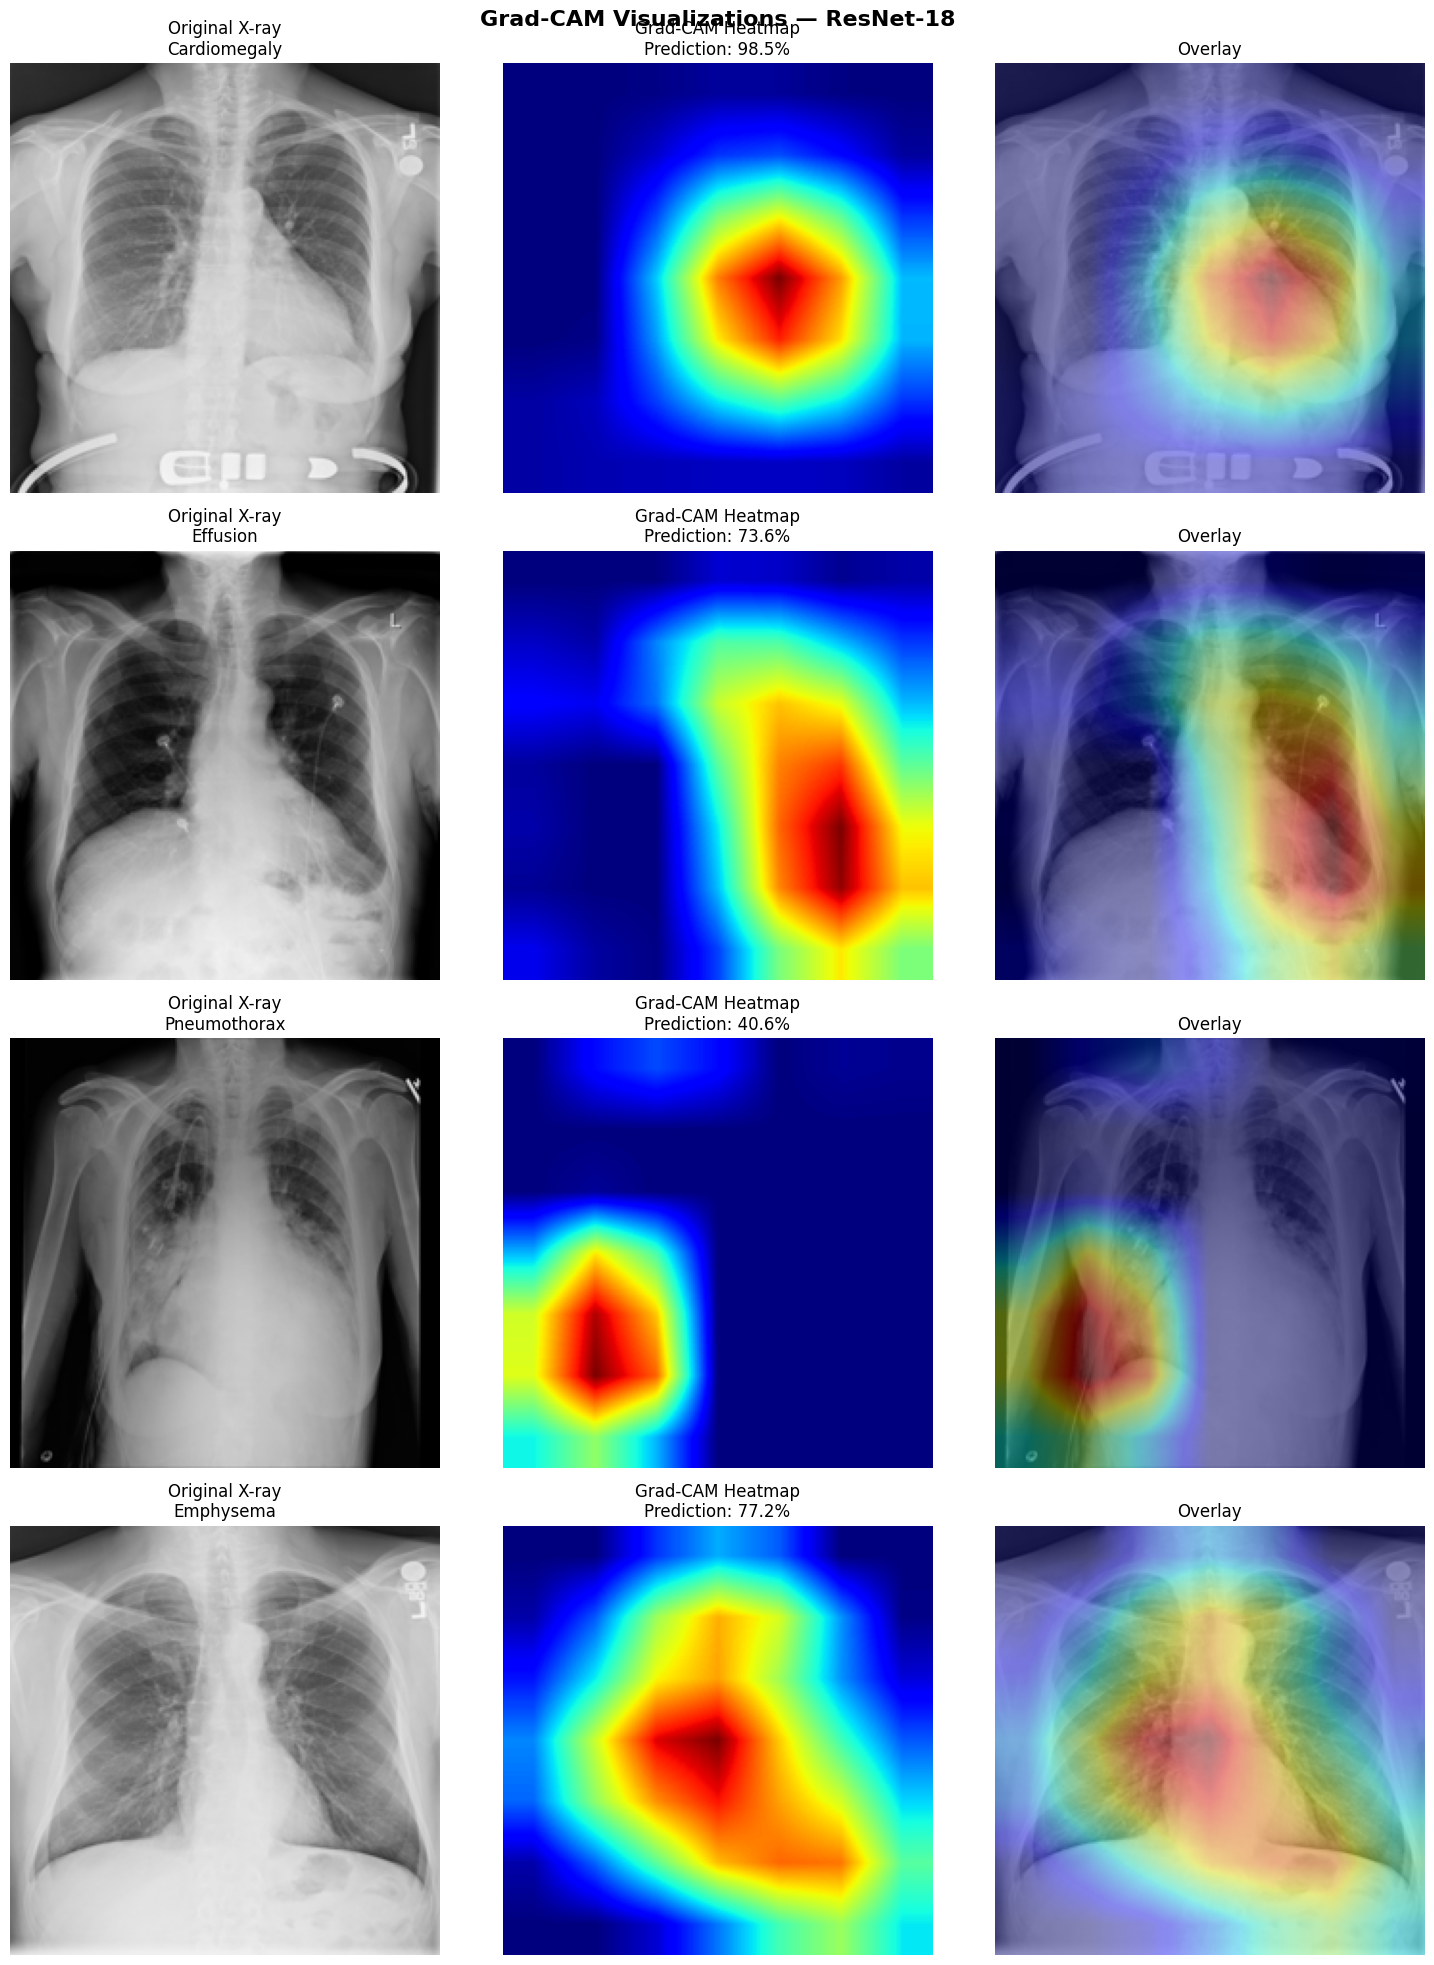

Grad-CAM visualizations saved.


In [15]:
# ============================================================
# CELL 14: Grad-CAM Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Load ResNet-18 with best checkpoint
resnet_model = get_resnet18()
resnet_model.load_state_dict(torch.load('/kaggle/working/ResNet18_best.pth',
                                         map_location=DEVICE))
resnet_model.eval()

# Target layer for ResNet-18
target_layer = resnet_model.layer4[-1].conv2
gradcam = GradCAM(resnet_model, target_layer)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Find sample images for 4 diseases
selected_diseases = ['Cardiomegaly', 'Effusion', 'Pneumothorax', 'Emphysema']
sample_images = []

for label_name in selected_diseases:
    positive_images = test_df[test_df[label_name] == 1]['Image Index'].values[:1]
    if len(positive_images) > 0:
        img_path = image_path_map.get(positive_images[0])
        if img_path:
            sample_images.append((img_path, LABELS.index(label_name), label_name))

# Plot
fig, axes = plt.subplots(len(sample_images), 3, figsize=(15, 5*len(sample_images)))

for i, (img_path, label_idx, label_name) in enumerate(sample_images):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)
    
    cam = gradcam.generate(img_tensor, label_idx)
    
    img_display = np.array(img.resize((224, 224)))
    heatmap = cm.jet(cam)[:, :, :3]
    heatmap = (heatmap * 255).astype(np.uint8)
    overlay = (0.6 * img_display + 0.4 * heatmap).astype(np.uint8)
    
    with torch.no_grad():
        output = resnet_model(img_tensor)
        prob = torch.sigmoid(output)[0, label_idx].item()
    
    axes[i, 0].imshow(img_display, cmap='gray')
    axes[i, 0].set_title(f'Original X-ray\n{label_name}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam, cmap='jet')
    axes[i, 1].set_title(f'Grad-CAM Heatmap\nPrediction: {prob:.1%}')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.suptitle('Grad-CAM Visualizations — ResNet-18', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM visualizations saved.")

In [16]:
# ============================================================
# CELL 15: RAG Integration with Real Model Outputs
# ============================================================
# Connect actual ResNet-18 predictions to RAG pipeline

import os
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

# ============================================================
# Step 1: Get real predictions from ResNet-18 on test samples
# ============================================================

resnet_model.eval()
sample_predictions = []
sample_true_labels = []

# Get predictions for 5 test samples
count = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = resnet_model(images)
        probs = torch.sigmoid(outputs)
        
        for j in range(len(images)):
            sample_predictions.append(probs[j].cpu().numpy())
            sample_true_labels.append(labels[j].numpy())
            count += 1
            if count >= 5:
                break
        if count >= 5:
            break

print(f"Collected {len(sample_predictions)} sample predictions")

# ============================================================
# Step 2: Build RAG knowledge base inline
# ============================================================

knowledge_chunks = [
    "DISEASE: Atelectasis\nDEFINITION: Collapse or incomplete expansion of lung tissue.\nRADIOLOGICAL FINDINGS: Increased opacity, volume loss, mediastinal shift.\nCAVEATS: Can be confused with consolidation. Label noise exists.",
    "DISEASE: Cardiomegaly\nDEFINITION: Enlarged heart with cardiothoracic ratio greater than 0.5.\nRADIOLOGICAL FINDINGS: Increased cardiac silhouette.\nCAVEATS: AP views artificially magnify cardiac size.",
    "DISEASE: Effusion\nDEFINITION: Abnormal fluid accumulation in pleural space.\nRADIOLOGICAL FINDINGS: Blunting of costophrenic angles, meniscus sign.\nCAVEATS: Small effusions may be missed.",
    "DISEASE: Infiltration\nDEFINITION: Material denser than air within lung parenchyma.\nRADIOLOGICAL FINDINGS: Ill-defined opacities.\nCAVEATS: Highly subjective term with high label noise.",
    "DISEASE: Mass\nDEFINITION: Pulmonary opacity greater than 3cm diameter.\nRADIOLOGICAL FINDINGS: Well or poorly defined opacity greater than 3cm.\nCAVEATS: Associated with malignancy.",
    "DISEASE: Nodule\nDEFINITION: Rounded opacity less than 3cm diameter.\nRADIOLOGICAL FINDINGS: Round or oval opacity less than 3cm.\nCAVEATS: Nodules less than 1cm difficult to detect on plain X-ray.",
    "DISEASE: Pneumonia\nDEFINITION: Infection causing inflammation of air sacs.\nRADIOLOGICAL FINDINGS: Lobar consolidation, air bronchograms.\nCAVEATS: Significant label noise. Many cases labeled as consolidation instead.",
    "DISEASE: Pneumothorax\nDEFINITION: Air in pleural space causing lung collapse.\nRADIOLOGICAL FINDINGS: Visible pleural line with absent lung markings.\nCAVEATS: Tension pneumothorax is a medical emergency.",
    "DISEASE: Consolidation\nDEFINITION: Replacement of alveolar air by fluid or cells.\nRADIOLOGICAL FINDINGS: Homogeneous opacity with air bronchograms.\nCAVEATS: Often overlaps with pneumonia label.",
    "DISEASE: Edema\nDEFINITION: Fluid accumulation in lung interstitium and alveoli.\nRADIOLOGICAL FINDINGS: Bilateral perihilar opacities, Kerley B lines.\nCAVEATS: Often co-occurs with cardiomegaly.",
    "DISEASE: Emphysema\nDEFINITION: Permanent enlargement of airspaces with alveolar wall destruction.\nRADIOLOGICAL FINDINGS: Hyperinflation, flattened diaphragms, bullae.\nCAVEATS: Plain X-ray underestimates severity compared to CT.",
    "DISEASE: Fibrosis\nDEFINITION: Scarring of lung tissue causing progressive function loss.\nRADIOLOGICAL FINDINGS: Reticular opacities, honeycombing.\nCAVEATS: CT is gold standard. Plain X-ray has limited sensitivity.",
    "DISEASE: Pleural_Thickening\nDEFINITION: Scarring and thickening of the pleura.\nRADIOLOGICAL FINDINGS: Irregular pleural surface, blunted costophrenic angles.\nCAVEATS: Difficult to distinguish from small pleural effusion.",
    "DISEASE: Hernia\nDEFINITION: Protrusion of abdominal contents through diaphragm.\nRADIOLOGICAL FINDINGS: Air or soft tissue density above diaphragm.\nCAVEATS: Severely underrepresented class. Rarest in dataset with only 227 cases.",
    "DATASET LIMITATIONS: Labels were NLP-mined from radiology reports. Estimated label error rate 10-20%. Not verified by radiologists.\nMODEL LIMITATIONS: Performance varies significantly across disease classes. Mean AUROC masks poor performance on rare classes.\nDISCLAIMER: This AI system is strictly assistive and must not replace professional medical judgment."
]

# Build embeddings
print("Building RAG index...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embed_model.encode(knowledge_chunks, show_progress_bar=True)
embeddings = np.array(embeddings).astype('float32')

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)
print(f"RAG index built with {index.ntotal} chunks")

# ============================================================
# Step 3: Generate RAG summaries for 3 sample predictions
# ============================================================

def generate_rag_summary(predictions, label_names, index, chunks, embed_model, threshold=0.5):
    predicted_diseases = [(label_names[i], float(predictions[i])) 
                         for i in range(len(predictions)) 
                         if predictions[i] >= threshold]
    predicted_diseases.sort(key=lambda x: x[1], reverse=True)
    
    # Build query
    if predicted_diseases:
        query = "Information about " + ", ".join([d[0] for d in predicted_diseases])
    else:
        query = "No findings chest X-ray normal"
    
    # Retrieve relevant chunks
    query_emb = embed_model.encode([query]).astype('float32')
    D, I = index.search(query_emb, 3)
    retrieved = [chunks[idx] for idx in I[0] if idx < len(chunks)]
    
    # Generate summary
    lines = []
    lines.append("=" * 60)
    lines.append("AI-ASSISTED CHEST X-RAY INTERPRETATION")
    lines.append("=" * 60)
    lines.append("")
    lines.append("DISCLAIMER: This is an AI-assisted analysis tool only.")
    lines.append("NOT a diagnostic tool. Must be reviewed by a qualified")
    lines.append("radiologist before any clinical decision is made.")
    lines.append("")
    
    if not predicted_diseases:
        lines.append("No findings detected above threshold (0.5).")
    else:
        lines.append("DETECTED FINDINGS:")
        lines.append("-" * 40)
        for label, prob in predicted_diseases:
            if prob >= 0.8:
                confidence = "High confidence"
            elif prob >= 0.65:
                confidence = "Moderate confidence"
            else:
                confidence = "Low confidence"
            lines.append(f"  {label}: {prob:.1%} ({confidence})")
    
    lines.append("")
    lines.append("KNOWLEDGE BASE CITATIONS:")
    lines.append("-" * 40)
    for i, chunk in enumerate(retrieved, 1):
        first_two_lines = '\n'.join(chunk.split('\n')[:2])
        lines.append(f"[Citation {i}] {first_two_lines}")
        lines.append("")
    
    lines.append("=" * 60)
    return '\n'.join(lines)

# Generate summaries for 3 samples
print("\nGenerating RAG-grounded summaries for 3 test samples:\n")
rag_summaries = []

for i in range(3):
    print(f"\n{'='*60}")
    print(f"SAMPLE {i+1}")
    print(f"True labels: {[LABELS[j] for j in range(14) if sample_true_labels[i][j] == 1]}")
    summary = generate_rag_summary(
        sample_predictions[i], LABELS, index, knowledge_chunks, embed_model
    )
    print(summary)
    rag_summaries.append(summary)

# Save summaries
with open('/kaggle/working/rag_summaries.txt', 'w', encoding='utf-8') as f:
    for i, summary in enumerate(rag_summaries):
        f.write(f"SAMPLE {i+1}\n")
        f.write(summary)
        f.write("\n\n")

print("\nRAG summaries saved to /kaggle/working/rag_summaries.txt")

ModuleNotFoundError: No module named 'faiss'